In [48]:
import torch
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image
import os
import json
import csv

class TextDetectionDataset(Dataset):
    def __init__(self, csv_file, images_dir, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms
        self.data = []
        
        with open(csv_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                try:
                    shape_attrs = json.loads(row["region_shape_attributes"])
                    text_label_data = json.loads(row["region_attributes"])
                    text_label = text_label_data.get("text", "")
                except json.JSONDecodeError:
                    print(f"Warning: Skipping row due to JSON decode error: {row}")
                    continue
                
                filename = row["filename"]
                if not all(k in shape_attrs for k in ["x", "y", "width", "height"]):
                    print(f"Warning: Skipping annotation for {filename} due to missing shape attributes: {shape_attrs}")
                    continue

                x = shape_attrs["x"]
                y = shape_attrs["y"]
                w = shape_attrs["width"]
                h = shape_attrs["height"]
                
                # Basic validation for bounding box coordinates
                if w <= 0 or h <= 0:
                    print(f"Warning: Skipping invalid bbox for {filename} (width/height <=0): w={w}, h={h}")
                    continue

                self.data.append({
                    "filename": filename,
                    "bbox": [x, y, x + w, y + h],
                    "text": text_label
                })
        
        self.image_data = {}
        for item in self.data:
            fname = item["filename"]
            if fname not in self.image_data:
                self.image_data[fname] = {
                    "filename": fname,
                    "boxes": [],
                    "labels": []
                }
            self.image_data[fname]["boxes"].append(item["bbox"])
            self.image_data[fname]["labels"].append(1) # 1 for "text" class
        
        self.image_keys = list(self.image_data.keys())

    def __len__(self):
        return len(self.image_keys)
    
    def __getitem__(self, idx):
        fname = self.image_keys[idx]
        img_path = os.path.join(self.images_dir, fname)
        
        try:
            img = Image.open(img_path).convert("L")
        except FileNotFoundError:
            print(f"Error: Image file not found {img_path}")
            # Return a dummy item or raise an error
            # For simplicity, returning None and it should be handled in collate_fn or training loop
            return None, None 
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return None, None


        boxes = torch.tensor(self.image_data[fname]["boxes"], dtype=torch.float32)
        labels = torch.tensor(self.image_data[fname]["labels"], dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx]) # Required by some evaluation metrics
        
        # Ensure bounding boxes are valid: x2 > x1 and y2 > y1
        valid_boxes = []
        for i in range(boxes.shape[0]):
            x1, y1, x2, y2 = boxes[i]
            if x2 > x1 and y2 > y1:
                valid_boxes.append(i)
        
        if not valid_boxes: # Handle cases where no valid boxes exist after filtering
             # Create a dummy valid box if none exist to avoid errors with empty tensors
            # This is a workaround; ideally, images without valid annotations should be handled or filtered
            # print(f"Warning: No valid boxes for {fname}. Adding a dummy box.")
            boxes = torch.tensor([[0, 0, 1, 1]], dtype=torch.float32)
            labels = torch.tensor([0], dtype=torch.int64) # background label
            target["boxes"] = boxes
            target["labels"] = labels
        else:
            target["boxes"] = boxes[valid_boxes]
            target["labels"] = labels[valid_boxes]


        if self.transforms:
            # Note: If using augmentations that affect bounding boxes (e.g. rotation, resize with aspect ratio change),
            # the transforms function needs to handle both image and target.
            img = self.transforms(img) # Apply to image
            
        return img, target

In [49]:
import torchvision.transforms as T

# Transforms for training data
train_transforms = T.Compose([
    T.RandomApply([T.ColorJitter(brightness=0.5, contrast=20)], p=0.7), # brightness=0.5, contrast=20
    T.RandomApply([T.GaussianBlur(kernel_size=(3, 101))], p=0.7),
    #T.RandomApply([T.GaussianBlur(kernel_size=41)], p=0.7),
    T.ToTensor()
])

tensor_transforms = T.Compose([
    T.ToTensor()
])

In [50]:
# Create the full dataset
full_dataset = TextDetectionDataset(
    csv_file='/kaggle/input/full-annotation-data/via_project_6Sep2024_20h21m_csv (1).csv',
    images_dir='/kaggle/input/complete-resized-journal-scans/resized_journal_scans'
)

In [51]:
len(full_dataset)

60

In [52]:
copy = full_dataset
full_dataset.transforms = tensor_transforms

# 1
copy.transforms = train_transforms
full_dataset = full_dataset + copy

# 2
copy.transforms = train_transforms
full_dataset = full_dataset + copy

# 3
copy.transforms = train_transforms
full_dataset = full_dataset + copy

# 4
copy.transforms = train_transforms
full_dataset = full_dataset + copy

# 5
copy.transforms = train_transforms
full_dataset = full_dataset + copy

In [53]:
len(full_dataset)

360

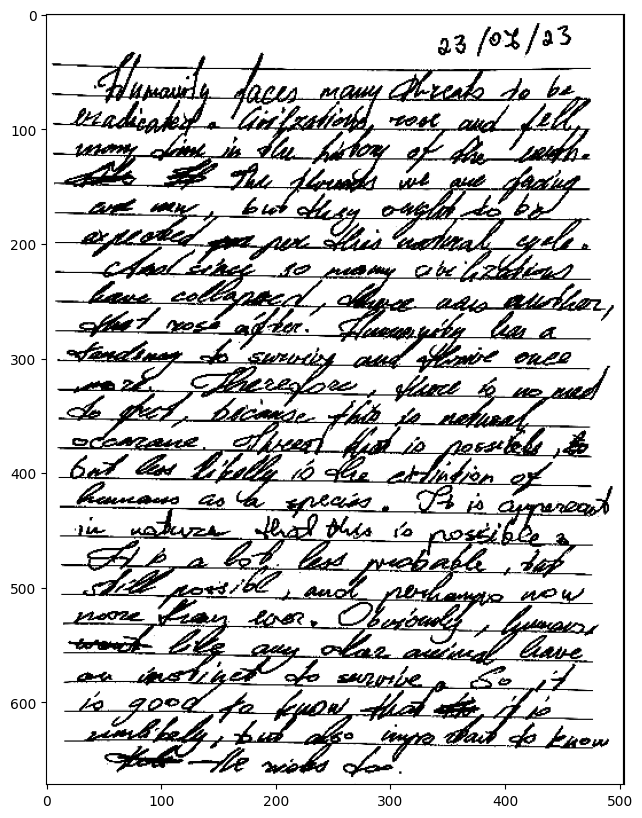

In [54]:
import matplotlib.pyplot as plt

example = full_dataset[0]

# Display the image tensor
plt.figure(figsize=(15, 10))
plt.imshow(example[0].squeeze().numpy(), cmap='gray')
plt.show()

In [55]:
# Split dataset
VAL_SPLIT = 0.3
dataset_size = len(full_dataset)
val_size = int(VAL_SPLIT * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [56]:
"""# Custom collate_fn to handle None items (e.g. from failed image loads)
def collate_fn_custom(batch):
    batch = list(filter(lambda x: x[0] is not None, batch)) # Filter out None items
    if not batch: # If all items were None (e.g., all images failed to load)
        return None, None
    return list(zip(*batch))"""

'# Custom collate_fn to handle None items (e.g. from failed image loads)\ndef collate_fn_custom(batch):\n    batch = list(filter(lambda x: x[0] is not None, batch)) # Filter out None items\n    if not batch: # If all items were None (e.g., all images failed to load)\n        return None, None\n    return list(zip(*batch))'

In [57]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn_custom, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn_custom, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Training samples: 252, Validation samples: 108


In [58]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def train_model(model, train_loader, val_loader, optimizer, scheduler, scaler, device, epochs):
    train_losses_log = [] # Log training losses
    val_map_log = []    # Log validation mAP

    # Initialize mAP metric
    # Note: `class_metrics=True` can give you per-class AP, which can be insightful.
    # `iou_thresholds` can be specified if you want mAP at different IoU levels.
    # Default is mAP @ IoU=0.50:0.05:0.95 (COCO style)
    map_metric = MeanAveragePrecision(iou_type="bbox").to(device)

    best_val_map = 0.0 # Initialize with 0 for mAP (higher is better)

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_idx, (imgs, targets) in enumerate(train_loader):
            if imgs is None or targets is None:
                print(f"Skipping a problematic batch in training: epoch {epoch+1}, batch_idx {batch_idx}")
                continue
            
            # Move to device
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Filter out images with no valid targets for training
            valid_train_targets = []
            valid_train_imgs = []
            for i in range(len(targets)):
                if targets[i]['boxes'].shape[0] > 0: # Ensure there are ground truth boxes
                    valid_train_targets.append(targets[i])
                    valid_train_imgs.append(imgs[i])
            
            if not valid_train_imgs: # If no images with valid targets in this batch
                print(f"Skipping training batch {batch_idx} in epoch {epoch+1} due to no valid targets.")
                continue
            
            imgs = valid_train_imgs
            targets = valid_train_targets

            with torch.cuda.amp.autocast(): # Mixed Precision
                loss_dict = model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())
        
            optimizer.zero_grad()
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        
            epoch_train_loss += losses.item()
            if batch_idx % 20 == 0: # Print progress every 20 batches
                 print(f"-- Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Train Loss: {losses.item():.4f}")

        avg_epoch_train_loss = epoch_train_loss / len(train_loader) if len(train_loader) > 0 else 0
        train_losses_log.append(avg_epoch_train_loss)
        
        # Validation phase
        model.eval()
        map_metric.reset() # Reset metric state at the start of each validation epoch

        with torch.no_grad():
            for imgs_val, targets_val in val_loader:
                if imgs_val is None or targets_val is None:
                    print(f"Skipping a problematic batch in validation: epoch {epoch+1}")
                    continue
                
                imgs_val = [img.to(device) for img in imgs_val]
                # Targets for mAP need to be on the same device and in the expected format
                # [{'boxes': tensor, 'labels': tensor}, ...]
                # The 'image_id' key in targets is not strictly needed by torchmetrics' MeanAveragePrecision
                # but other keys like 'area' or 'iscrowd' might be if you use COCO-style evaluation deeply.
                # For basic mAP, 'boxes' and 'labels' are key.
                
                formatted_targets_val = []
                valid_indices_for_preds = [] # Keep track of images that had valid GT for model input

                for i, t_val in enumerate(targets_val):
                    if 'boxes' not in t_val or 'labels' not in t_val:
                        print(f"Warning: Target for image {i} in validation batch missing 'boxes' or 'labels'. Skipping for mAP.")
                        continue
                    
                    formatted_targets_val.append({
                        "boxes": t_val["boxes"].to(device),
                        "labels": t_val["labels"].to(device)
                    })
                    valid_indices_for_preds.append(i)
                
                imgs_val_filtered = [imgs_val[i] for i in valid_indices_for_preds]

                predictions = model(imgs_val_filtered) # Get predictions from the model
                map_metric.update(predictions, formatted_targets_val)

        try:
            val_map_results = map_metric.compute()
            current_val_map = val_map_results['map'].item() # Get the main mAP score
            val_map_log.append(current_val_map)
            print(f"Epoch {epoch+1} | Train loss: {avg_epoch_train_loss:.4f} | Val mAP: {current_val_map:.4f} | LR: {scheduler.get_last_lr()} \n")
        except Exception as e:
            print(f"Error computing mAP for epoch {epoch+1}: {e}")
            current_val_map = 0.0 # Default if computation fails
            val_map_log.append(current_val_map) # Log a zero or handle as appropriate
            print(f"Epoch {epoch+1} | Train loss: {avg_epoch_train_loss:.4f} | Val mAP: (Error computing)")


        if scheduler: # Check if a scheduler is provided
            scheduler.step()

    return train_losses_log, val_map_log

---

In [59]:
from torch.optim.lr_scheduler import StepLR
import torch.optim as optim
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT) # Use new weights argument
num_classes = 2  # Background + Text
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4) # AdamW is often preferred
scaler = torch.cuda.amp.GradScaler()

scheduler = StepLR(optimizer, step_size=3, gamma=0.5) 

NUM_EPOCHS = 25

<ipython-input-59-eb0216a3ae3b>:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [60]:
train_losses, val_losses = train_model(model, train_loader, val_loader, optimizer, scheduler, scaler, device, epochs=NUM_EPOCHS)

<ipython-input-58-97cff3ff925d>:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Mixed Precision


-- Epoch 1/25 | Batch 0/126 | Train Loss: 5.7233
-- Epoch 1/25 | Batch 20/126 | Train Loss: 1.1115
-- Epoch 1/25 | Batch 40/126 | Train Loss: 1.0357
-- Epoch 1/25 | Batch 60/126 | Train Loss: 1.1159
-- Epoch 1/25 | Batch 80/126 | Train Loss: 1.2124
-- Epoch 1/25 | Batch 100/126 | Train Loss: 0.7786
-- Epoch 1/25 | Batch 120/126 | Train Loss: 0.7178
Epoch 1 | Train loss: 1.1825 | Val mAP: 0.4520 | LR: [0.0001] 

-- Epoch 2/25 | Batch 0/126 | Train Loss: 1.0785
-- Epoch 2/25 | Batch 20/126 | Train Loss: 0.8405
-- Epoch 2/25 | Batch 40/126 | Train Loss: 0.8213
-- Epoch 2/25 | Batch 60/126 | Train Loss: 0.9556
-- Epoch 2/25 | Batch 80/126 | Train Loss: 0.9213
-- Epoch 2/25 | Batch 100/126 | Train Loss: 0.6790
-- Epoch 2/25 | Batch 120/126 | Train Loss: 0.6942
Epoch 2 | Train loss: 0.8302 | Val mAP: 0.4990 | LR: [0.0001] 

-- Epoch 3/25 | Batch 0/126 | Train Loss: 0.8628
-- Epoch 3/25 | Batch 20/126 | Train Loss: 0.8050
-- Epoch 3/25 | Batch 40/126 | Train Loss: 0.6279
-- Epoch 3/25 | Batch

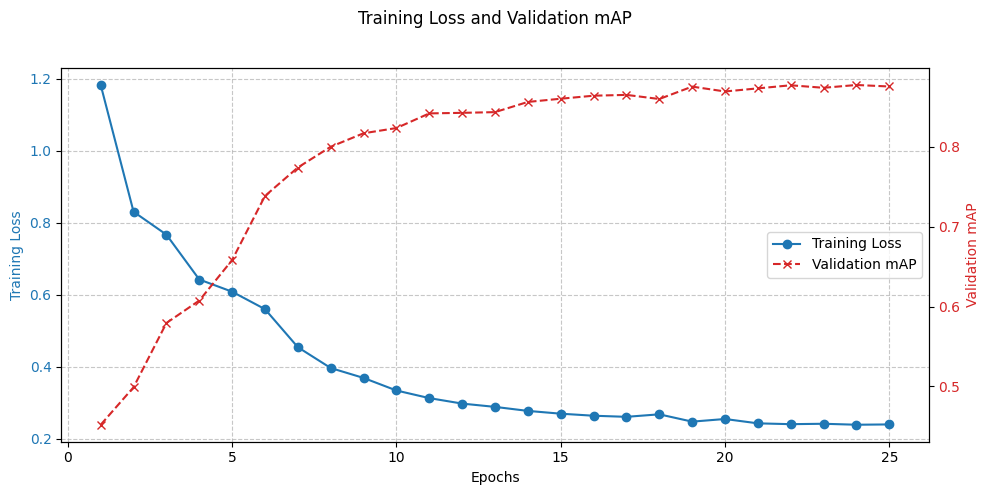

In [61]:
# Plotting Training Loss and Validation mAP
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(range(1, len(train_losses) + 1), train_losses, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Validation mAP', color=color)
ax2.plot(range(1, len(val_losses) + 1), val_losses, color=color, marker='x', linestyle='--', label='Validation mAP')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Training Loss and Validation mAP')
# To add legends from both axes:
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

fig.tight_layout(rect=[0, 0, 1, 0.96])  # adjust layout to make room for suptitle
plt.show()

# Inference
---

In [67]:
import cv2

def predict_and_visualize(model, image_path, device, threshold=0.5):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Image not found or empty at {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_image = image.copy()
    
    transform = T.Compose([T.ToTensor()]) # Use the same ToTensor as validation
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)
    
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    
    detected = False
    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            detected = True
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(orig_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(orig_image, f"{scores[i]:.2f}", (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    if not detected:
        print(f"No text detected above threshold {threshold} in {image_path}")
    
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)
    plt.title(f"Predictions for {os.path.basename(image_path)}")
    plt.axis("off")
    plt.show()

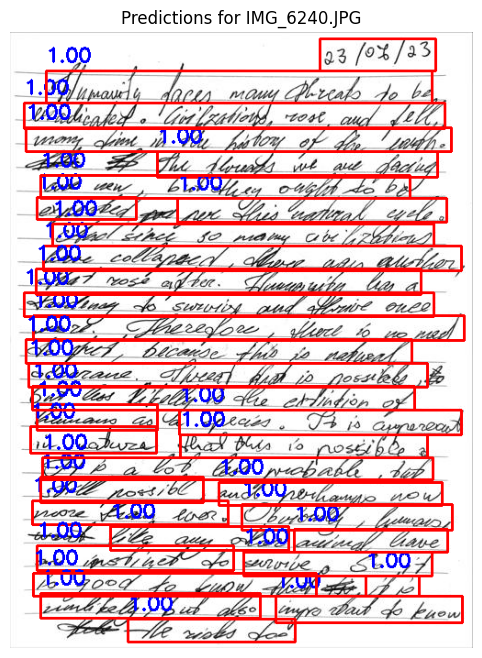

In [69]:
predict_and_visualize(model, '/kaggle/input/complete-resized-journal-scans/resized_journal_scans/IMG_6240.JPG', device=device, threshold=0.6)

In [70]:
torch.save(model.state_dict(), 'annotation_model.pth')